In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42
)

x_matrix = X_train.to_numpy()
bias_column = np.ones((x_matrix.shape[0], 1))
x_matrix = np.hstack((bias_column, x_matrix))
y_numeric = y_train.iloc[:, 0].map({'M': 1, 'B': 0})
y_matrix = y_numeric.to_numpy() 
cofs = np.linalg.inv(x_matrix.T.dot(x_matrix)).dot(x_matrix.T).dot(y_matrix)
print(f"Coefficients: {cofs}")
x_tester = X_test.to_numpy()
bias_column = np.ones((x_tester.shape[0], 1))
x_tester2 = np.hstack((bias_column, x_tester))
y_numeric_test = y_test.iloc[:, 0].map({'M': 1, 'B': 0})
y_matrix_test = y_numeric_test.to_numpy()
y_matrix_test
predictions = []
for xvals in x_tester2:
    prediction = np.sum(xvals*cofs)
    if prediction <= 0.5:
        prediction = 0
    else: 
        prediction = 1
    predictions.append(prediction)
total_correct = 0
index = 0
for y_hat in predictions:
    if y_hat == y_matrix_test[index]:
        total_correct += 1
    index += 1
print(f" Ratio of correct to incorrect classifications: {total_correct/(len(y_matrix_test)-total_correct)}")

Coefficients: [-2.05632034e+00 -1.97130218e-01  2.79472278e-03  2.27758664e-02
  3.28622398e-04 -4.11490191e-01 -5.00171192e+00  1.00587030e+00
  4.91570446e+00 -3.38393701e-01  5.81425644e+00  4.32261922e-01
 -1.26325368e-02 -8.24736376e-03 -1.24507529e-03  1.80785086e+01
 -2.20798677e+00 -4.27375913e+00  1.81589526e+01 -1.19449435e+00
 -3.01203668e+00  2.14438989e-01  9.61718848e-03 -8.71176396e-03
 -9.61253395e-04  1.32384962e-01  7.62670138e-01  6.15742798e-01
 -1.32619828e+00  1.02113249e+00  1.27363832e+00]
 Ratio of correct to incorrect classifications: 21.8


In [3]:
t_values = np.arange(0, 1.0, 0.01)

In [4]:
P = 43
N = 71

In [5]:

TPR = []
FPR = []
for t in t_values:
    TP = 0
    FP = 0
    predictions = []
    index = 0
    for xvals in x_tester2:
        prediction = np.sum(xvals*cofs)
        if prediction <= t:
            prediction = 0
        else: 
            prediction = 1
        predictions.append(prediction)
    for y_hat in predictions:
        if y_hat == 1:
            if y_matrix_test[index] == 1:
                TP += 1
            else:
                FP += 1
        index+=1
    TPR.append(TP/P)
    FPR.append(FP/N)

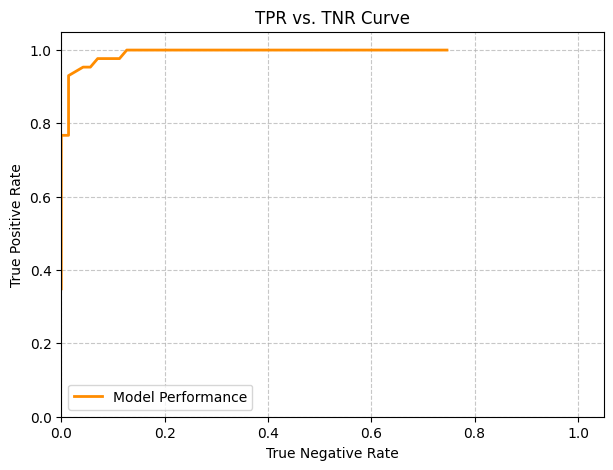

In [6]:
plt.figure(figsize=(7, 5))
plt.plot(FPR, TPR, color="darkorange", lw=2, label="Model Performance")

# Formatting the plot
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.xlabel("True Negative Rate")
plt.ylabel("True Positive Rate")
plt.title("TPR vs. TNR Curve")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(loc="lower left")
plt.show()

In [7]:
TPR_sorted = np.sort(TPR)
FPR_sorted = np.sort(FPR)

In [8]:
auc = 0.0
for i in range(1, len(TPR)):
    width = FPR_sorted[i] - FPR_sorted[i-1]
    avg_height = (TPR_sorted[i] + TPR_sorted[i-1]) / 2.0
    auc += width * avg_height

In [9]:
auc

np.float64(0.7392728463806092)

In [10]:
x_mean = np.mean(x_matrix)
x_std = np.std(x_matrix)

In [11]:
x_normalized = (x_matrix - x_mean) / x_std

In [12]:
cofs = np.linalg.inv(x_normalized.T.dot(x_normalized)).dot(x_normalized.T).dot(y_matrix)
print(f"Coefficients: {cofs}")


Coefficients: [-7.85759432e+03 -4.42339294e+01  6.27102277e-01  5.11066127e+00
  7.37394379e-02 -9.23343356e+01 -1.12233176e+03  2.25706519e+02
  1.10303235e+03 -7.59318632e+01  1.30466341e+03  9.69948616e+01
 -2.83462887e+00 -1.85062453e+00 -2.79380859e-01  4.05662955e+03
 -4.95450728e+02 -9.58987159e+02  4.07468146e+03 -2.68030735e+02
 -6.75856206e+02  4.81178546e+01  2.15799905e+00 -1.95482694e+00
 -2.15695201e-01  2.97056216e+01  1.71135414e+02  1.38166317e+02
 -2.97585450e+02  2.29131231e+02  2.85788054e+02]


In [13]:
X

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [14]:
from datetime import datetime
data = [
    ("August 1, 1958", 4), ("January 7, 1963", 5), ("January 7, 1968", 6), ("May 16, 1971", 8),
    ("March 2, 1974", 10), ("December 31, 1975", 13), ("May 29, 1978", 15), ("March 22, 1981", 18),
    ("November 1, 1981", 20), ("February 17, 1985", 22), ("April 3, 1988", 25), ("February 3, 1991", 29),
    ("January 1, 1995", 32), ("January 10, 1999", 33), ("January 7, 2001", 34), ("June 30, 2002", 37),
    ("January 8, 2006", 39), ("May 14, 2007", 41), ("May 12, 2008", 42), ("May 11, 2009", 44),
    ("January 22, 2012", 45), ("January 27, 2013", 46), ("January 26, 2014", 49), ("April 10, 2016", 47),
    ("January 22, 2017", 49), ("January 21, 2018", 50), ("January 27, 2019", 55), ("August 29, 2021", 58),
    ("July 10, 2022", 60), ("January 22, 2023", 63), ("July 9, 2023", 66), ("January 21, 2024", 68),
    ("July 14, 2024", 73), ("July 13, 2025", 78), ("July 12, 2026", 82)
]

base_date = datetime(1958, 1, 1)
t_values = []
p_values = []
for date_str, price in data:
    d = datetime.strptime(date_str, "%B %d, %Y")
    days = (d - base_date).days
    t = days / 365
    t_values.append(t)
    p_values.append(price)
t_arr = np.array(t_values)
p_arr = np.array(p_values)
A = np.vstack([np.ones_like(t_arr), t_arr]).T
b = np.log(p_arr)
x = np.linalg.lstsq(A, b, rcond=None)[0]
ln_alpha, k = x
alpha = np.exp(ln_alpha)
print(f"k ={k}, alpha = {alpha}")

k =0.03818906036194478, alpha = 5.877724398650995


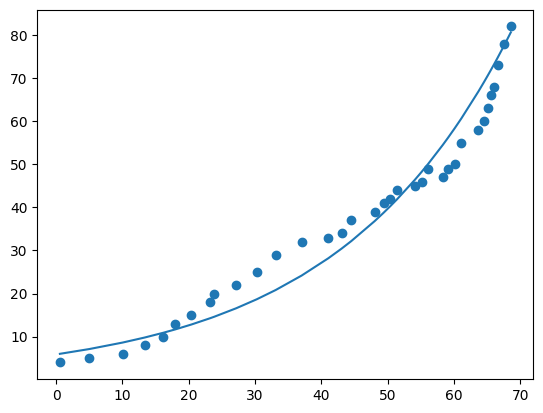

In [15]:
predicted_prices = []
for t in t_values:
    predicted_prices.append(alpha*np.e**(k*t))
plt.plot(t_values, predicted_prices)
plt.scatter(t_values, p_values)
plt.show()

In [16]:
x = np.array([-2.2, -2.0, -1.8, -1.6, -1.4, -1.2, -1.0, -0.8, -0.6, -0.4, -0.2, 0.0, 
              0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2])
y = np.array([-2.96, 0.60, 2.18, 2.54, 2.31, 1.68, 1.16, 0.81, 0.38, 0.36, 0.69, 1.04, 
              1.42, 1.68, 1.99, 2.06, 1.60, 1.21, 0.45, -0.08, -0.41, 0.18, 1.72])

A = np.vstack([x**5, x**4, x**3, x**2, x, np.ones_like(x)]).T
b = y
x_pred = np.linalg.lstsq(A, b)[0]


In [17]:
x_pred

array([ 0.40027583, -0.18549782, -2.1287474 ,  0.56580959,  1.99322868,
        1.0188833 ])

In [18]:
def predict_y(x):
    return x_pred[0]*x**1 + x_pred[1]*x**2 + x_pred[2]*x**3 + x_pred[3]*x**4 + x_pred[4]*x**5

In [19]:
x_arr = np.arange(-2.2, 2.4, 0.2)
y_arr = []
for x_val in x_arr:
    y_arr.append(predict_y(x_val))

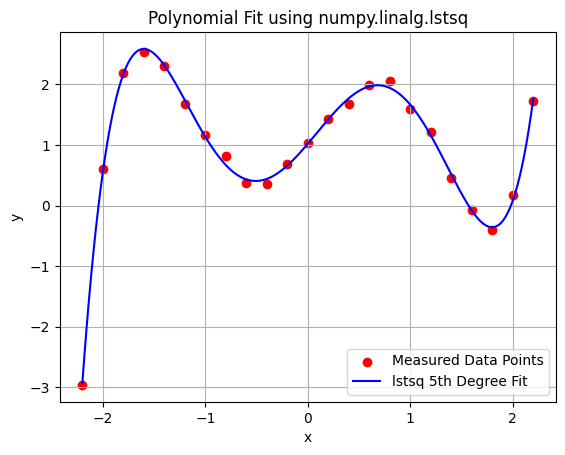

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the measured data points
x = np.array([-2.2, -2.0, -1.8, -1.6, -1.4, -1.2, -1.0, -0.8, -0.6, -0.4, -0.2, 0.0, 
              0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2])
y = np.array([-2.96, 0.60, 2.18, 2.54, 2.31, 1.68, 1.16, 0.81, 0.38, 0.36, 0.69, 1.04, 
              1.42, 1.68, 1.99, 2.06, 1.60, 1.21, 0.45, -0.08, -0.41, 0.18, 1.72])

A = np.vstack([x**5, x**4, x**3, x**2, x, np.ones_like(x)]).T
coefficients = np.linalg.lstsq(A, y)[0]

x_pred = np.linspace(min(x), max(x), 200)
A_pred = np.vstack([x_pred**5, x_pred**4, x_pred**3, x_pred**2, x_pred, np.ones_like(x_pred)]).T
y_pred = A_pred @ coefficients

plt.scatter(x, y, color='red', label='Measured Data Points')
plt.plot(x_pred, y_pred, color='blue', label='lstsq 5th Degree Fit')
plt.title('Polynomial Fit using numpy.linalg.lstsq')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


In [21]:
def bilinear_interpolate(img, x, y):
    height, width = img.shape[:2]

    if x < 0 or x > width - 1 or y < 0 or y > height - 1:
        return 0.0  

    x0 = int(np.floor(x))
    y0 = int(np.floor(y))

    x1 = min(x0 + 1, width - 1)
    y1 = min(y0 + 1, height - 1)

    f00 = img[y0, x0]
    f10 = img[y0, x1]
    f01 = img[y1, x0]
    f11 = img[y1, x1]
    dx = x - x0
    dy = y - y0

    return (1 - dx) * (1 - dy) * f00 + dx * (1 - dy) * f10 + (1 - dx) * dy * f01 + dx * dy * f11

In [22]:
from PIL import Image

In [23]:
img = Image.open("bacEmbedded.png")
img = np.array(img)
angle = np.radians(30)
sin = np.sin(angle)
cos = np.cos(angle)
height, width = img.shape[:2]

x_center = (width-1)/2.0
y_center = (height-1)/2.0

canvas = np.zeros_like(img, dtype=float)

for y in range(height):
    for x in range(width):
        x_shifted = x - x_center
        y_shifted = y - y_center   
        
        x_back = x_shifted * cos + y_shifted * sin + x_center
        y_back = -x_shifted * sin + y_shifted * cos + y_center
        
        canvas[y, x] = bilinear_interpolate(img, x_back, y_back)
rot_img = Image.fromarray(canvas)
rot_img = rot_img.convert('L')
rot_img.save("rotated.png")
rot_img.show()